<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/SQ4DS_Lecture_1.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Beginner Data Science with Python

## Python, NumPy, Pandas, Matplotlib, Seaborn, and Scikit-learn

This notebook is a **concept-first beginner course** for data science.

The goal is not to memorize library commands. The goal is to understand:

- what each tool is designed to represent and solve,
- why a particular data structure or operation is useful,
- how the tools fit together in a data-science workflow,
- and how to recognize which tool should be used for a particular problem.

The course therefore follows a repeated pattern:

**Concept → mental model → small example → exercise → interpretation**

You should try the exercises before looking at any solution code.

---

## What you will learn

By the end of the notebook, you should be able to:

1. Write and reason about basic Python programs.
2. Work with variables, strings, numbers, booleans, collections, conditions, loops, and functions.
3. Understand NumPy arrays and vectorized numerical computation.
4. Use Pandas Series and DataFrames to inspect, clean, filter, group, and combine data.
5. Build appropriate plots with Matplotlib.
6. Use Seaborn for statistically-oriented exploratory visualizations.
7. Understand the basic machine-learning workflow with Scikit-learn.
8. Separate **features**, **targets**, **training data**, and **test data**.
9. Evaluate simple regression and classification models.
10. Complete a small end-to-end data-science project.

## What this course intentionally emphasizes

This is a **theory-heavy beginner course**. Knowing that `df.groupby("city")["sales"].mean()` works is less important than understanding:

> "I have observations belonging to different groups. I want one summary value per group."

Once you understand the operation conceptually, learning the syntax becomes much easier.

# 0. The Data Science Mental Model

Data science is often presented as a collection of Python libraries. A better mental model is a sequence of questions.

### Step 1 — What is the problem?

Examples:

- What factors are associated with higher sales?
- Which customers are likely to leave?
- Is there a relationship between study time and exam score?
- Can we predict house prices?

### Step 2 — What data represents the problem?

A dataset usually contains **observations**.

For example, if we study students:

| student | study_hours | attendance | exam_score |
|---|---:|---:|---:|
| A | 2.0 | 70 | 55 |
| B | 5.0 | 90 | 81 |
| C | 4.0 | 85 | 76 |

Each row is an observation. The columns describe properties of that observation.

### Step 3 — Understand the data

We inspect:

- shape,
- types,
- missing values,
- unusual values,
- distributions,
- relationships between variables.

### Step 4 — Communicate what we found

Visualization helps us see patterns that are difficult to see from a table.

### Step 5 — Model when prediction is required

Machine learning is useful when we want a system that learns patterns from data and uses them to make predictions on new observations.

---

## The role of each tool

**Python** is the programming language.

**NumPy** is mainly about efficient numerical arrays and mathematical operations.

**Pandas** is mainly about labeled/tabular data.

**Matplotlib** provides low-level, flexible plotting primitives.

**Seaborn** builds higher-level statistical visualizations on top of Matplotlib.

**Scikit-learn** provides standard machine-learning algorithms and the surrounding workflow: preprocessing, splitting data, fitting models, and evaluation.

A useful summary is:

> Python controls the logic. NumPy handles numerical structure. Pandas handles tables. Matplotlib/Seaborn help you see data. Scikit-learn helps you build and evaluate predictive models.

# 1. Setup

The first code cell imports the main tools used throughout the course.

If you are running this notebook locally, install the libraries with:

```bash
pip install numpy pandas matplotlib seaborn scikit-learn jupyter
```

You do **not** need to understand every import yet.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_iris


NumPy: 2.3.5
Pandas: 2.2.3


# Part I — Python Fundamentals

Python is the foundation for everything that follows.

Before using data-science libraries, you need to understand a few ideas:

- values,
- variables,
- types,
- operations,
- control flow,
- collections,
- functions,
- and exceptions.

These are not just programming details. They determine how you manipulate data.

---

# 2. Values, Variables, and Types

A **value** is a piece of information such as:

- `10`
- `3.14`
- `"Nigeria"`
- `True`

A **variable** is a name associated with a value.

Think of a variable as a label pointing to an object, rather than a permanent physical box.

```python
age = 25
```

This associates the name `age` with the integer value `25`.

## Why types matter

A computer does not treat all values as interchangeable.

For example:

```python
10 + 5
```

means numerical addition.

But:

```python
"10" + "5"
```

means string concatenation and produces `"105"`.

The same symbols can have different meaning depending on the object's type.

In [ ]:
age = 25
height = 1.75
name = "Ada"
is_student = True

print(age, type(age))
print(height, type(height))
print(name, type(name))
print(is_student, type(is_student))

25 <class 'int'>
1.75 <class 'float'>
Ada <class 'str'>
True <class 'bool'>


## Core beginner types

| Type | Typical meaning | Example |
|---|---|---|
| `int` | whole number | `7` |
| `float` | decimal number | `7.5` |
| `str` | text | `"hello"` |
| `bool` | true/false state | `True` |
| `NoneType` | absence of a value | `None` |

Do not focus only on memorizing names. Ask:

> What kind of thing is this value, and what operations make sense for it?

## Exercise 1 — Variables and types

Create variables for:

- your age,
- a decimal number representing your height,
- your first name,
- whether you are currently learning data science.

Print each value and its type.

Then answer:

1. Which variables are numeric?
2. Which variable represents a logical state?
3. What happens when you add an integer and a float?

# 3. Operators and Expressions

An **expression** is something Python can evaluate to produce a value.

Examples:

```python
2 + 3
10 / 2
5 > 3
"data" + "science"
```

Arithmetic operators include:

- `+` addition
- `-` subtraction
- `*` multiplication
- `/` division
- `//` floor division
- `%` remainder
- `**` exponentiation

Comparison operators produce booleans:

- `==`
- `!=`
- `<`
- `<=`
- `>`
- `>=`

Logical operators combine conditions:

- `and`
- `or`
- `not`

A key idea is that conditions do not directly "do" something. They produce `True` or `False`, which can then control program flow.

In [ ]:
x = 17
y = 5

print("Addition:", x + y)
print("Division:", x / y)
print("Floor division:", x // y)
print("Remainder:", x % y)
print("Power:", x ** 2)

print("x > y:", x > y)
print("x == y:", x == y)

Addition: 22
Division: 3.4
Floor division: 3
Remainder: 2
Power: 289
x > y: True
x == y: False


## Exercise 2 — Build a simple calculation

Suppose a store sells:

- 3 notebooks at 250 each,
- 2 pens at 100 each.

Calculate the total cost.

Then suppose the customer receives a 10% discount. Calculate the amount after the discount.

Try to write the calculation as expressions using variables, rather than putting everything into one line.

# 4. Strings

A string is a sequence of text characters.

Strings are important in data science because real datasets contain many categories, names, labels, descriptions, dates, and identifiers.

Useful operations include:

- indexing,
- slicing,
- changing case,
- replacing text,
- splitting text,
- joining text.

A string behaves like an ordered sequence, which means individual characters have positions.

In [ ]:
text = "Data Science"

print(text[0])
print(text[0:4])
print(text.lower())
print(text.upper())
print(text.replace("Science", "Analysis"))

D
Data
data science
DATA SCIENCE
Data Analysis


## A useful mental model for indexing

Python uses **zero-based indexing**.

For:

```text
D a t a
0 1 2 3
```

the first character is at position `0`.

Negative indexes count from the end:

```text
D a t a
-4 -3 -2 -1
```

This convention appears throughout Python and many data-science libraries.

## Exercise 3 — String processing

Given:

```python
sentence = "Python makes data science practical"
```

Do the following:

1. Find its length.
2. Extract `"Python"`.
3. Convert it to uppercase.
4. Replace `"practical"` with `"powerful"`.
5. Split the sentence into individual words.

Then explain why string operations are useful when preparing real-world data.

# 5. Collections: Lists, Tuples, Dictionaries, and Sets

Data science requires handling groups of values.

### Lists

A list is an ordered, mutable collection.

```python
scores = [70, 81, 65, 92]
```

Lists are useful when:

- order matters,
- values may change,
- you need a general Python collection.

### Tuples

A tuple is ordered but immutable.

```python
point = (10, 20)
```

### Dictionaries

A dictionary stores key-value relationships.

```python
student = {"name": "Ada", "score": 91}
```

This is especially important because many data structures are conceptually mappings from a **key** to a **value**.

### Sets

A set stores unique values.

```python
cities = {"Lagos", "Abuja", "Lagos"}
```

The duplicate disappears because sets represent membership, not repeated ordered entries.

In [ ]:
scores = [70, 81, 65, 92]
print(scores[0])
print(len(scores))

student = {"name": "Ada", "score": 91}
print(student["name"])
print(student["score"])

cities = {"Lagos", "Abuja", "Lagos"}
print(cities)

70
4
Ada
91
{'Abuja', 'Lagos'}


## Exercise 4 — Choose the right collection

For each problem, decide which Python collection is most appropriate and explain why:

1. A sequence of monthly sales where order matters.
2. A person's coordinates `(latitude, longitude)`.
3. A mapping from employee ID to salary.
4. A collection of unique customer countries.

There can be more than one technically valid answer, but your reasoning should focus on what the data structure is meant to represent.

# 6. Conditions and Control Flow

Programs become useful when they can make decisions.

An `if` statement asks whether a condition is true.

Conceptually:

> **IF condition is true → execute this block**

An `elif` adds another condition.

An `else` handles the remaining case.

Indentation is part of Python syntax. The indentation tells Python which statements belong to a block.

In [ ]:
score = 78

if score >= 70:
    grade = "A"
elif score >= 50:
    grade = "B"
else:
    grade = "C"

print(grade)

A


## Exercise 5 — Business rule

Write a program that takes a customer's order total.

- At least 50,000 → 15% discount
- At least 20,000 → 10% discount
- Otherwise → no discount

Calculate the final amount.

Focus on writing clear conditions rather than trying to make the code as short as possible.

# 7. Loops

A loop repeats a block of instructions.

Two common loop types are:

- `for`: repeat over a sequence or other iterable
- `while`: repeat while a condition remains true

A loop is useful when you have a repeated operation.

However, there is an important transition coming later:

> In NumPy and Pandas, many repeated operations can be expressed as **vectorized operations** instead of explicit Python loops.

This often makes code clearer and numerical work much faster.

In [ ]:
scores = [70, 81, 65, 92]

total = 0
for score in scores:
    total += score

average = total / len(scores)
print("Average:", average)

Average: 77.0


## Exercise 6 — Loop practice

Given:

```python
numbers = [3, 7, 10, 12, 15]
```

Use a loop to:

1. calculate the sum,
2. count how many numbers are greater than 9,
3. create a new list containing the squares.

Then compare the logic you wrote with the idea of doing the same operation with NumPy.

# 8. Functions

A function packages a reusable operation.

Instead of repeatedly writing the same logic, we define it once and call it whenever needed.

A function has:

- inputs, called **parameters**,
- a body containing the computation,
- an optional output, returned with `return`.

Functions are fundamental in data science because they let you isolate transformations and make code easier to test and reason about.

In [ ]:
def calculate_discount(price, rate):
    return price * (1 - rate)

final_price = calculate_discount(10000, 0.10)
print(final_price)

9000.0


## Parameters vs arguments

In:

```python
def multiply(a, b):
    return a * b
```

`a` and `b` are parameters.

In:

```python
multiply(3, 4)
```

`3` and `4` are arguments.

A good beginner habit is to give functions one clear responsibility.

Instead of making a huge function called `process_everything()`, create smaller functions such as:

- `clean_names()`
- `calculate_average()`
- `plot_sales()`

This becomes increasingly important as projects become larger.

## Exercise 7 — Write functions

Write:

1. `mean(values)` — returns the arithmetic mean.
2. `count_positive(values)` — counts values greater than zero.
3. `normalize(value, minimum, maximum)` — converts a value to the 0–1 range.

For the third function, use:

```text
normalized = (value - minimum) / (maximum - minimum)
```

Think about what should happen if `maximum == minimum`. You do not have to implement the error handling yet, but identify the problem.

# 9. Errors and Exceptions

Errors are normal in programming.

Common beginner errors include:

- `SyntaxError`: the code cannot be parsed.
- `NameError`: a name does not exist.
- `TypeError`: an operation is incompatible with the object's type.
- `IndexError`: an index is outside the valid range.
- `KeyError`: a dictionary key does not exist.

The important skill is not avoiding every error. It is learning to read the traceback and identify:

1. what kind of error occurred,
2. where it occurred,
3. what the program expected,
4. what actually happened.

In [ ]:
try:
    value = int("42")
    print(value)
except ValueError:
    print("The conversion failed.")

42


# Part II — NumPy

NumPy's central abstraction is the **ndarray**: a multidimensional numerical array.

Why is this important?

Python lists are flexible general-purpose containers. NumPy arrays are designed for numerical computation.

A NumPy array provides:

- a regular numerical structure,
- a known shape,
- a known data type,
- efficient mathematical operations,
- vectorized computation.

---

# 10. Arrays, Shape, and Dimensions

Imagine a table of numbers.

- 1 dimension → a vector-like sequence
- 2 dimensions → rows and columns
- 3+ dimensions → additional axes

The **shape** tells us how many elements exist along each axis.

For example:

```text
shape = (3, 4)
```

means:

> 3 rows and 4 columns

The number of dimensions is called `ndim`.

In [ ]:
a = np.array([10, 20, 30, 40])
b = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

print("a:", a)
print("a shape:", a.shape)
print("a ndim:", a.ndim)

print("b:")
print(b)
print("b shape:", b.shape)
print("b ndim:", b.ndim)

a: [10 20 30 40]
a shape: (4,)
a ndim: 1
b:
[[1 2 3]
 [4 5 6]]
b shape: (2, 3)
b ndim: 2


## Exercise 8 — Read array structure

Create an array with shape `(4, 3)`.

Then print:

- the array,
- `shape`,
- `ndim`,
- `size`,
- `dtype`.

Explain in words what each property tells you.

# 11. Indexing and Slicing in NumPy

NumPy uses indexing concepts similar to Python lists, but extends them to multiple dimensions.

For a 2D array:

```python
array[row, column]
```

Think of the first index as selecting an observation/row and the second index as selecting a variable/column.

This connection becomes very important later when working with data matrices for machine learning.

In [ ]:
matrix = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

print("First row:", matrix[0])
print("Element at row 2, column 3:", matrix[1, 2])
print("First two rows:")
print(matrix[:2])
print("Second column:")
print(matrix[:, 1])

First row: [10 20 30]
Element at row 2, column 3: 60
First two rows:
[[10 20 30]
 [40 50 60]]
Second column:
[20 50 80]


# 12. Vectorization

A major NumPy idea is **vectorization**.

Suppose:

```python
x = np.array([1, 2, 3])
```

We can write:

```python
x * 10
```

instead of explicitly looping through the elements.

The operation is conceptually:

```text
[1, 2, 3] × 10
→ [10, 20, 30]
```

Vectorization lets us express the mathematical intent directly.

This matters because numerical libraries can perform these operations efficiently in compiled code.

It also changes how you think about computation:

> Instead of asking "How do I loop over every value?", ask "What mathematical operation do I want to apply to the whole array?"

In [ ]:
x = np.array([1, 2, 3, 4, 5])

print(x * 10)
print(x + 2)
print(x ** 2)
print(np.sqrt(x))

[10 20 30 40 50]
[3 4 5 6 7]
[ 1  4  9 16 25]
[1.         1.41421356 1.73205081 2.         2.23606798]


## Exercise 9 — Vectorized calculation

Create:

```python
prices = np.array([100, 250, 400, 120])
```

A 15% discount means keeping 85% of the original price.

Use one vectorized expression to calculate all discounted prices.

Then calculate the average discounted price.

Do not use a Python `for` loop.

# 13. Broadcasting

Broadcasting is NumPy's mechanism for applying operations between arrays with compatible shapes.

For example:

```text
[10, 20, 30]
     +
   100
```

becomes:

```text
[110, 120, 130]
```

The scalar `100` is conceptually applied to each element.

Broadcasting becomes more interesting with matrices. NumPy compares dimensions from the right and allows dimensions when they are equal or when one dimension is `1`.

You do not need to memorize the complete broadcasting rules immediately. Begin by checking shapes.

In [ ]:
sales = np.array([
    [100, 120, 140],
    [200, 220, 240]
])

tax_rates = 1.075

after_tax = sales * tax_rates
print(after_tax)

[[107.5 129.  150.5]
 [215.  236.5 258. ]]


## Exercise 10 — Broadcasting with a column

Create a `(3, 1)` array containing tax rates for three products and multiply it by a `(3, 4)` sales matrix.

First predict whether the shapes are compatible.

Then test it.

This exercise is intended to make you think about **shape compatibility**, not just get a number.

# 14. NumPy Aggregation and Statistics

NumPy provides common mathematical operations:

- `sum`
- `mean`
- `median`
- `min`
- `max`
- `std`
- `var`

Aggregation reduces many values into a summary.

For example, a column of 1,000 temperatures can be reduced to one mean temperature.

With multidimensional data, the `axis` argument determines **which direction is reduced**.

This is one of the most important conceptual ideas in NumPy.

In [ ]:
data = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

print("Overall mean:", data.mean())
print("Mean by column:", data.mean(axis=0))
print("Mean by row:", data.mean(axis=1))

Overall mean: 50.0
Mean by column: [40. 50. 60.]
Mean by row: [20. 50. 80.]


### Understanding `axis`

For this `(3, 3)` matrix:

- `axis=0` collapses the rows, producing one value per column.
- `axis=1` collapses the columns, producing one value per row.

A useful test is:

> What should remain after I reduce this axis?

If you want one result for each column, the column dimension should remain.

## Exercise 11 — Statistical summary

Create an array representing:

- 5 students,
- 3 subjects.

Rows represent students and columns represent subjects.

Calculate:

1. overall mean score,
2. mean score per subject,
3. mean score per student,
4. highest score,
5. lowest score,
6. standard deviation.

Explain what each statistic tells you about the dataset.

# Part III — Pandas

NumPy gives us numerical arrays. Data science often needs something more expressive:

- column names,
- row labels,
- mixed data types,
- missing values,
- grouping,
- joining,
- filtering.

This is where Pandas becomes useful.

The two central objects are:

**Series** — one labeled column.

**DataFrame** — a labeled table made up of rows and columns.

A good mental model is:

> A DataFrame is a table where each column is a Series.

In [ ]:
students = pd.DataFrame({
    "name": ["Ada", "Bola", "Chidi", "Dami", "Efe", "Fatima"],
    "department": ["Math", "CS", "Math", "Physics", "CS", "Physics"],
    "study_hours": [2.0, 5.0, 3.0, 4.0, 6.0, 1.5],
    "attendance": [70, 92, 78, 88, 95, 60],
    "score": [55, 84, 65, 79, 91, 48]
})

students

,name,department,study_hours,attendance,score
0,Ada,Math,2.0,70,55
1,Bola,CS,5.0,92,84
2,Chidi,Math,3.0,78,65
3,Dami,Physics,4.0,88,79
4,Efe,CS,6.0,95,91
5,Fatima,Physics,1.5,60,48


# 15. DataFrame Anatomy

The table above has:

- rows = observations,
- columns = variables/features,
- index = row labels,
- values = the actual data.

This distinction is fundamental.

For example:

> `score` is a variable measured for every student.

The fact that `score` is a column is a structural decision about how the data is organized.

---

## Data types

A column may contain:

- integer values,
- floating-point values,
- strings/categories,
- dates,
- booleans.

Pandas uses dtypes to keep track of these.

You should inspect dtypes because many operations depend on them.

In [ ]:
print(students.shape)
print()
print(students.dtypes)
print()
print(students.info())

(6, 5)

name            object
department      object
study_hours    float64
attendance       int64
score            int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         6 non-null      object 
 1   department   6 non-null      object 
 2   study_hours  6 non-null      float64
 3   attendance   6 non-null      int64  
 4   score        6 non-null      int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 372.0+ bytes
None


## Exercise 12 — Inspect a DataFrame

Using `students`, find:

1. the number of rows,
2. the number of columns,
3. the column names,
4. the data type of `score`,
5. the first three rows,
6. the last two rows.

Then explain the difference between `shape` and `dtypes`.

# 16. Selecting Columns and Rows

Pandas supports several ways to select data.

Common patterns:

```python
df["score"]
```

selects one column as a Series.

```python
df[["score", "attendance"]]
```

selects multiple columns as a DataFrame.

For label-based selection, use `.loc`.

For position-based selection, use `.iloc`.

Conceptually:

- `.loc` → select according to labels/conditions.
- `.iloc` → select according to integer positions.

This distinction is extremely useful when a DataFrame has a meaningful index.

In [ ]:
print("One column:")
print(students["score"])

print("\nMultiple columns:")
print(students[["study_hours", "score"]])

print("\nFirst three rows by position:")
print(students.iloc[:3])

print("\nRows labeled 0 and 2:")
print(students.loc[[0, 2]])

One column:
0    55
1    84
2    65
3    79
4    91
5    48
Name: score, dtype: int64

Multiple columns:
   study_hours  score
0          2.0     55
1          5.0     84
2          3.0     65
3          4.0     79
4          6.0     91
5          1.5     48

First three rows by position:
    name department  study_hours  attendance  score
0    Ada       Math          2.0          70     55
1   Bola         CS          5.0          92     84
2  Chidi       Math          3.0          78     65

Rows labeled 0 and 2:
    name department  study_hours  attendance  score
0    Ada       Math          2.0          70     55
2  Chidi       Math          3.0          78     65


# 17. Filtering Data

Filtering answers questions such as:

> Which students scored above 70?

The conceptual structure is:

1. create a boolean condition,
2. use that boolean mask to select rows.

Example:

```python
students["score"] > 70
```

produces a Series of `True` and `False` values.

Pandas then keeps the rows where the condition is `True`.

This is closely related to NumPy boolean indexing.

In [ ]:
high_scores = students[students["score"] > 70]
high_scores

,name,department,study_hours,attendance,score
1,Bola,CS,5.0,92,84
3,Dami,Physics,4.0,88,79
4,Efe,CS,6.0,95,91


## Multiple conditions

Use:

- `&` for AND
- `|` for OR
- `~` for NOT

Put each condition in parentheses.

Example:

```python
students[(students["score"] > 70) & (students["attendance"] > 80)]
```

This means:

> keep rows where score is above 70 **and** attendance is above 80.

## Exercise 13 — Filtering

Answer each question with a Pandas expression:

1. Which students study at least 4 hours?
2. Which students scored below 60?
3. Which students have attendance above 80 and score above 75?
4. Which students are in Computer Science (`CS`)?

Then explain what the boolean mask is doing conceptually.

# 18. Creating and Transforming Columns

A powerful Pandas pattern is creating a new column from existing columns.

For example:

```python
students["passed"] = students["score"] >= 50
```

This creates a boolean variable.

This is a simple example of **feature engineering**:

> constructing a useful variable from existing information.

In real projects, feature engineering can include:

- extracting year/month from dates,
- converting raw measurements,
- creating ratios,
- categorizing values,
- combining fields.

In [ ]:
students["passed"] = students["score"] >= 50
students["performance_ratio"] = students["score"] / students["attendance"]

students

,name,department,study_hours,attendance,score,passed,performance_ratio
0,Ada,Math,2.0,70,55,True,0.785714
1,Bola,CS,5.0,92,84,True,0.913043
2,Chidi,Math,3.0,78,65,True,0.833333
3,Dami,Physics,4.0,88,79,True,0.897727
4,Efe,CS,6.0,95,91,True,0.957895
5,Fatima,Physics,1.5,60,48,False,0.800000


## Exercise 14 — Feature creation

Create:

1. `study_category` where study hours below 3 are `"Low"`, 3 to 5 are `"Medium"`, and above 5 are `"High"`.
2. `attendance_ok` indicating attendance of at least 75.
3. `score_squared`.

You may use regular Python logic, `np.where`, or `pd.cut`.

The objective is to understand the idea of creating derived variables.

# 19. Missing Data

Real datasets are incomplete.

A missing value might mean:

- the measurement was not collected,
- the user did not answer,
- the value was lost,
- the field is not applicable.

Missingness is not automatically the same thing as zero.

For example:

- `salary = 0`
- `salary = missing`

mean different things.

Pandas commonly represents missing values with `NaN` or `pd.NA`.

Typical strategies include:

- dropping rows/columns,
- filling with a meaningful value,
- using a statistic such as a median,
- using a domain-specific rule,
- explicitly modeling missingness.

The correct strategy depends on why the data is missing.

In [ ]:
missing_demo = pd.DataFrame({
    "age": [20, 21, np.nan, 24, 25],
    "score": [70, 82, 76, np.nan, 91]
})

print(missing_demo.isna())
print()
print(missing_demo.isna().sum())

     age  score
0  False  False
1  False  False
2   True  False
3  False   True
4  False  False

age      1
score    1
dtype: int64


## Exercise 15 — Missing-data reasoning

For the dataset above:

1. Identify which columns have missing values.
2. Calculate the mean score ignoring missing values.
3. Fill missing scores with the median score.
4. Explain one reason why filling a missing value with `0` might be misleading.

# 20. Sorting and Aggregation

Sorting answers questions such as:

> Which observations have the highest score?

Aggregation answers questions such as:

> What is the average score by department?

Common aggregation operations include:

- mean,
- sum,
- count,
- median,
- min,
- max.

The important concept is **grouped analysis**.

When we use `groupby`, we conceptually:

1. divide observations into groups,
2. compute a statistic inside each group,
3. combine the results.

In [ ]:
print(students.sort_values("score", ascending=False))

department_summary = students.groupby("department")["score"].mean()
print()
print(department_summary)

     name department  study_hours  attendance  score  passed  performance_ratio
4     Efe         CS          6.0          95     91    True           0.957895
1    Bola         CS          5.0          92     84    True           0.913043
3    Dami    Physics          4.0          88     79    True           0.897727
2   Chidi       Math          3.0          78     65    True           0.833333
0     Ada       Math          2.0          70     55    True           0.785714
5  Fatima    Physics          1.5          60     48   False           0.800000

department
CS         87.5
Math       60.0
Physics    63.5
Name: score, dtype: float64


## Exercise 16 — Grouped analysis

Using `students`:

1. Calculate the average study hours by department.
2. Find the highest score in each department.
3. Count students in each department.
4. Calculate the average attendance for each department.

Then write one sentence explaining why `groupby` is useful in data analysis.

# 21. Merging and Joining Data

In practical projects, information is often stored across multiple tables.

For example:

### Students

| student_id | name |
|---|---|
| 1 | Ada |
| 2 | Bola |

### Results

| student_id | score |
|---|---:|
| 1 | 91 |
| 2 | 84 |

The shared `student_id` lets us combine the tables.

This is a **relational data** idea.

A merge can behave like:

- inner join,
- left join,
- right join,
- outer join.

The key question is:

> Which rows should survive the combination, and which key identifies matching observations?

In [ ]:
students_info = pd.DataFrame({
    "student_id": [1, 2, 3],
    "name": ["Ada", "Bola", "Chidi"]
})

results = pd.DataFrame({
    "student_id": [1, 2, 3],
    "score": [91, 84, 76]
})

merged = students_info.merge(results, on="student_id", how="inner")
merged

,student_id,name,score
0,1,Ada,91
1,2,Bola,84
2,3,Chidi,76


## Exercise 17 — Merge reasoning

Create two DataFrames:

- one containing customer IDs and names,
- another containing customer IDs and spending.

Merge them.

Then change the second table so one customer ID does not appear.

Compare an `inner` merge with a `left` merge.

Before executing, predict how many rows each result should contain and why.

# 22. Reading and Writing Data

In actual data-science work, data often comes from:

- CSV files,
- Excel files,
- databases,
- APIs,
- JSON,
- Parquet.

For CSV:

```python
df = pd.read_csv("data.csv")
```

To save:

```python
df.to_csv("cleaned_data.csv", index=False)
```

The important concept is that file loading is part of the **data ingestion** stage.

After loading a file, do not immediately model it. Inspect it first.

## Practical inspection checklist

After loading a dataset, ask:

1. How many observations do I have?
2. What does one row represent?
3. What does each column represent?
4. What are the data types?
5. Are there missing values?
6. Are there duplicate rows?
7. Are there suspicious or impossible values?
8. What is the target variable, if this is a prediction problem?

# Part IV — Matplotlib

Visualization is not decoration.

A plot is a way of representing relationships in the data so that human pattern recognition can operate on them.

Different plots answer different questions.

### Common plot types

**Line plot**  
Useful for values changing over an ordered variable such as time.

**Bar chart**  
Useful for comparing categories.

**Histogram**  
Useful for examining the distribution of a numerical variable.

**Scatter plot**  
Useful for examining the relationship between two numerical variables.

The most important plotting skill is not syntax. It is choosing a representation that matches the question.

# 23. Matplotlib Mental Model

Matplotlib can be understood through two major objects:

**Figure** — the whole canvas.

**Axes** — an individual plotting area.

A common pattern is:

```python
fig, ax = plt.subplots()
ax.plot(...)
```

Thinking in terms of `fig` and `ax` makes larger visualizations much easier to manage.

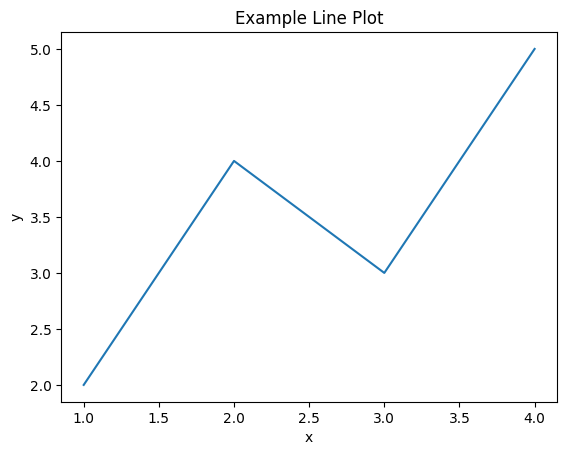

In [ ]:
fig, ax = plt.subplots()

ax.plot([1, 2, 3, 4], [2, 4, 3, 5])
ax.set_title("Example Line Plot")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

# 24. Histograms

A histogram groups numerical values into intervals called **bins**.

It helps answer:

- Where are most observations?
- Is the distribution roughly symmetric?
- Is it skewed?
- Are there multiple clusters?
- Are there unusually extreme observations?

A histogram does not display individual observations as separate categories. It summarizes their distribution.

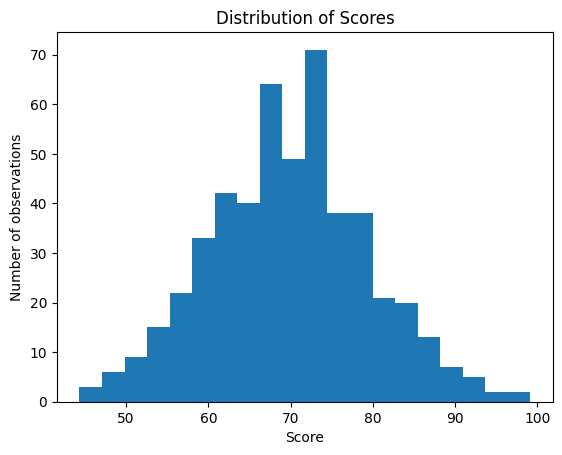

In [ ]:
rng = np.random.default_rng(42)
scores = rng.normal(loc=70, scale=10, size=500)

fig, ax = plt.subplots()
ax.hist(scores, bins=20)
ax.set_title("Distribution of Scores")
ax.set_xlabel("Score")
ax.set_ylabel("Number of observations")
plt.show()

## Exercise 18 — Distribution

Generate 1,000 random values from a normal distribution with mean 50 and standard deviation 8.

Create a histogram.

Then answer:

1. Around what value is the distribution centered?
2. How spread out are the values?
3. What would happen if the standard deviation were much larger?

# 25. Scatter Plots

A scatter plot represents paired observations.

For each observation:

- x-coordinate = one variable
- y-coordinate = another variable

It helps us investigate whether two numerical variables appear related.

Possible patterns include:

- positive association,
- negative association,
- little visible association,
- nonlinear relationship,
- clusters,
- outliers.

A scatter plot does **not** by itself establish causation.

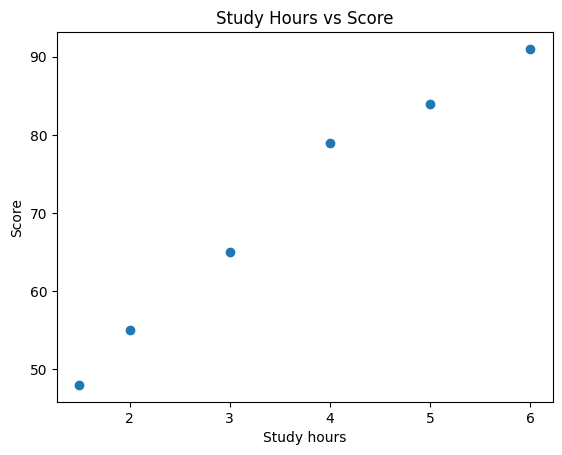

In [ ]:
fig, ax = plt.subplots()
ax.scatter(students["study_hours"], students["score"])
ax.set_title("Study Hours vs Score")
ax.set_xlabel("Study hours")
ax.set_ylabel("Score")
plt.show()

## Exercise 19 — Read the plot

Create a scatter plot of:

- attendance vs score.

Then describe the pattern without making causal claims.

A good description might say:

> "Higher attendance appears to be associated with higher scores in this small sample."

Avoid saying:

> "Attendance causes higher scores."

unless you have an appropriate causal research design.

# Part V — Seaborn

Seaborn is a statistical visualization library built around Matplotlib.

Its purpose is to make common analytical plots easier to create and often more informative by default.

Seaborn works particularly well with DataFrames because columns can be referred to by name.

Common plots include:

- `histplot`
- `boxplot`
- `scatterplot`
- `countplot`
- `barplot`
- `lineplot`

The key idea is the same as Matplotlib:

> choose the plot based on the analytical question.

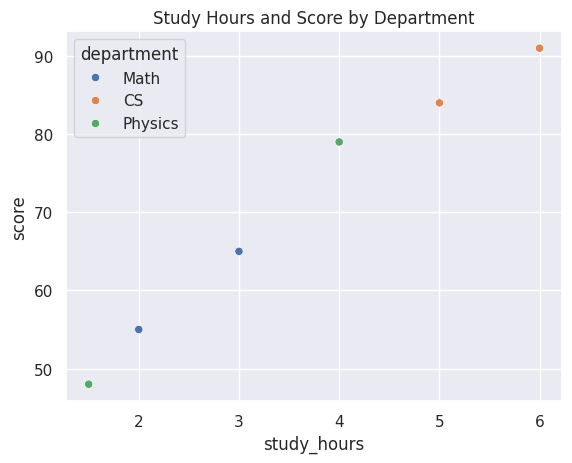

In [ ]:
sns.set_theme()

fig, ax = plt.subplots()
sns.scatterplot(data=students, x="study_hours", y="score", hue="department", ax=ax)
ax.set_title("Study Hours and Score by Department")
plt.show()

# 26. Box Plots

A box plot summarizes the distribution of a numerical variable.

The central components represent ideas such as:

- median,
- lower and upper quartiles,
- spread,
- possible unusually distant observations.

Box plots are especially useful for comparing distributions across categories.

For example:

> Do different departments have different score distributions?

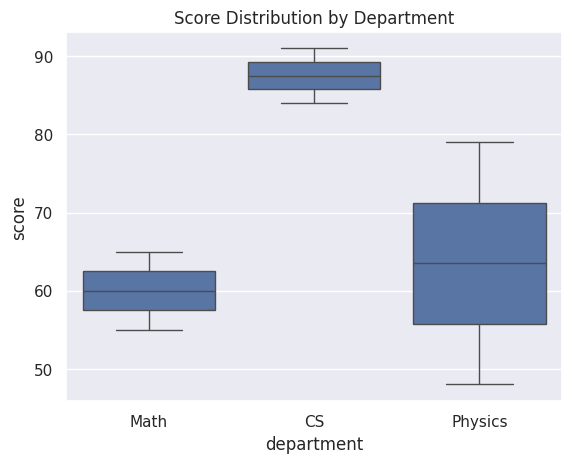

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(data=students, x="department", y="score", ax=ax)
ax.set_title("Score Distribution by Department")
plt.show()

## Exercise 20 — Compare categories

Create a box plot comparing score distributions by department.

Because the dataset is small, treat your conclusions cautiously.

Answer:

1. Which department has the highest median in this sample?
2. Which department appears to have the widest spread?
3. Why can a small dataset make these conclusions unstable?

# 27. Choosing a Visualization

Use this reasoning table:

| Question | Useful starting plot |
|---|---|
| How is one numerical variable distributed? | Histogram |
| How do two numerical variables relate? | Scatter plot |
| How do categories compare? | Bar chart / box plot |
| How does a value change over time? | Line plot |
| How many observations belong to each category? | Count plot |
| How do distributions differ across groups? | Box plot / violin plot |

This is a starting point, not a rigid rule.

Good visualization requires asking:

> What relationship or structure am I trying to make visible?

# Part VI — Scikit-learn

Scikit-learn is a machine-learning library.

Before using algorithms, understand the central distinction:

### Descriptive analysis

We are trying to understand the data.

Examples:

- What is the average?
- How are values distributed?
- Are variables associated?

### Predictive modeling

We are trying to learn a function from data that can make predictions.

Examples:

- Predict house price.
- Predict whether a customer will leave.
- Classify an image into a category.

Machine learning is therefore not just "running an algorithm." The workflow around the algorithm matters just as much.

# 28. Features and Target

Suppose we want to predict exam score.

Possible inputs:

- study hours,
- attendance.

The value we want to predict is:

- exam score.

In machine learning terminology:

**Features (`X`)** = information given to the model.

**Target (`y`)** = value the model is asked to predict.

A common matrix representation is:

```text
X =
[
  [2.0, 70],
  [5.0, 92],
  [3.0, 78]
]

y =
[
  55,
  84,
  65
]
```

Notice that `X` usually has shape:

```text
(number_of_samples, number_of_features)
```

This convention connects directly to NumPy's concepts of arrays and shape.

In [ ]:
X = students[["study_hours", "attendance"]]
y = students["score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6, 2)
y shape: (6,)


## Exercise 21 — Identify X and y

Imagine a dataset containing:

- age,
- annual_income,
- number_of_purchases,
- churned.

Suppose the goal is to predict whether a customer churns.

Which column is `y`?

Which columns belong in `X`?

Explain your reasoning in words before writing code.

# 29. Training and Test Data

Suppose a model is trained and evaluated on exactly the same observations.

That can be misleading.

Why?

Because a model may appear to perform well simply because it has learned patterns specific to the data it already saw.

We therefore often divide data into:

**Training set** — used to learn model parameters.

**Test set** — held back until evaluation.

This is part of the broader idea of **generalization**:

> How well does the learned relationship work on new observations?

In [ ]:
X_demo = np.arange(20).reshape(-1, 1)
y_demo = 2 * X_demo.ravel() + 1

X_train, X_test, y_train, y_test = train_test_split(
    X_demo,
    y_demo,
    test_size=0.25,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (15, 1) (15,)
Test: (5, 1) (5,)


## Exercise 22 — Split reasoning

Create a small dataset of 100 observations.

Split it into 80% training and 20% testing.

Then answer:

1. Why must the test set be kept separate?
2. What might happen if you repeatedly tune the model by looking at test performance?
3. Why is `random_state` useful when learning?

# 30. Linear Regression

Linear regression models a numerical target as a weighted combination of input variables.

For one feature:

```text
y = b0 + b1*x
```

For multiple features:

```text
y = b0 + b1*x1 + b2*x2 + ... + bp*xp
```

The model learns coefficients that minimize an error criterion, commonly squared error for ordinary least squares regression.

The important conceptual idea is:

> The model is trying to find a relationship between inputs and a continuous output.

In [ ]:
X = students[["study_hours", "attendance"]]
y = students["score"]

# For teaching purposes, use a larger synthetic dataset below so the split is meaningful.
rng = np.random.default_rng(7)

n = 200
study_hours = rng.uniform(1, 8, n)
attendance = rng.uniform(50, 100, n)
noise = rng.normal(0, 4, n)

score = 25 + 7 * study_hours + 0.35 * attendance + noise
score = np.clip(score, 0, 100)

data_ml = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "score": score
})

X = data_ml[["study_hours", "attendance"]]
y = data_ml["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 31.345552681148774
Coefficients: [6.27998044 0.2892805 ]


# 31. Regression Evaluation

A regression model predicts numbers, so we need numerical error metrics.

## Mean Squared Error (MSE)

MSE calculates:

1. prediction error for each observation,
2. square the errors,
3. average the squared errors.

Squaring makes large errors count more heavily.

## Root Mean Squared Error (RMSE)

RMSE is the square root of MSE.

Its advantage is interpretability: it has the same units as the target variable.

## R²

R² describes how much of the variation in the target is explained by the fitted model relative to a baseline formulation.

Do not treat R² as a universal "quality score." Its interpretation depends on the problem and dataset.

In [ ]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 10.382447555442331
RMSE: 3.222180559100053
R²: 0.9450759521860546


## Exercise 23 — Regression analysis

Using `data_ml`:

1. Train a linear regression model using only `study_hours`.
2. Evaluate it using RMSE and R².
3. Train another model using both `study_hours` and `attendance`.
4. Compare the metrics.

Then explain why adding a feature can sometimes improve predictions but does not guarantee better performance on unseen data.

# 32. Classification

Classification predicts a category rather than a continuous number.

Examples:

- spam / not spam,
- disease / no disease,
- customer churn / retained,
- species A / species B / species C.

A classification model learns a decision rule or probability model that maps input features to classes.

One common algorithm is **logistic regression**.

Despite its name, logistic regression is commonly used for classification.

# 33. The Iris Dataset

The Iris dataset is a classic beginner dataset.

Each observation describes a flower using four numerical measurements:

- sepal length,
- sepal width,
- petal length,
- petal width.

The target is the flower species.

Scikit-learn includes this dataset, so we can work with it without downloading anything.

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

X shape: (150, 4)
Target shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


## Exercise 24 — Understand the dataset

Before fitting a model, answer:

1. How many observations are there?
2. How many features?
3. How many target classes?
4. What does one row of `X` represent?
5. What does one element of `y` represent?

This habit is more important than memorizing any machine-learning command.

# 34. Logistic Regression for Classification

For binary classification, logistic regression models the probability of a class using a logistic function.

Instead of predicting an unrestricted number like linear regression, it maps a linear combination of features into a probability between 0 and 1.

For multiple classes, Scikit-learn can use a multiclass strategy.

Again, the important workflow is:

1. define `X` and `y`,
2. split data,
3. fit only on training data,
4. predict the test data,
5. evaluate.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9666666666666667


# 35. Accuracy and the Confusion Matrix

## Accuracy

Accuracy is:

```text
correct predictions / total predictions
```

It is intuitive, but it can be misleading when classes are highly imbalanced.

## Confusion matrix

A confusion matrix shows how actual classes and predicted classes correspond.

For multiple classes, rows/columns show where predictions were correct or confused between categories.

The purpose is not just to get a single score. It helps us inspect **what kinds of mistakes the model makes**.

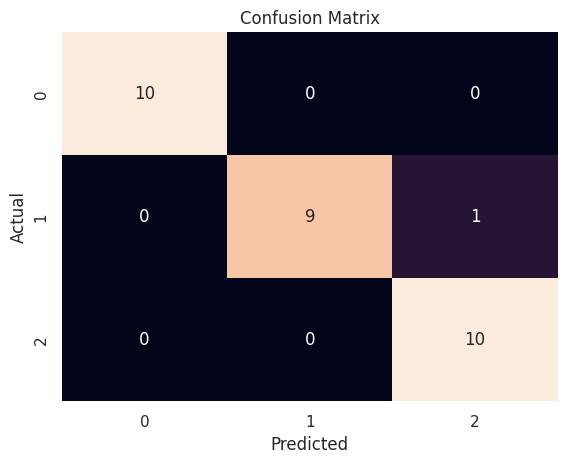

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    ax=ax
)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.show()

## Exercise 25 — Interpret the confusion matrix

Look at the confusion matrix above.

Answer:

1. Which predictions are correct?
2. Which classes are being confused?
3. Why is a confusion matrix often more informative than accuracy alone?

Do not focus on the exact number. Focus on what the matrix represents.

# 36. Feature Scaling

Some algorithms are sensitive to feature scale.

Imagine:

- `age` ranges from 18 to 80,
- `annual_income` ranges from 20,000 to 20,000,000.

A numerical feature measured on a much larger scale can affect optimization and distance-based calculations.

**Standardization** transforms a feature using:

```text
z = (x - mean) / standard deviation
```

After standardization, the transformed feature is centered around 0 with a scale related to its standard deviation.

Not every algorithm requires scaling equally, but building the habit of asking whether scale matters is important.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original means:", X.mean(axis=0))
print("Scaled means:", X_scaled.mean(axis=0))
print("Scaled standard deviations:", X_scaled.std(axis=0))

Original means: [5.84333333 3.05733333 3.758      1.19933333]
Scaled means: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Scaled standard deviations: [1. 1. 1. 1.]


# 37. Pipelines

A machine-learning pipeline chains transformations and a model together.

Conceptually:

```text
raw features
   ↓
scaling
   ↓
model
   ↓
prediction
```

Pipelines help prevent mistakes such as fitting preprocessing on the entire dataset before splitting.

They also make workflows reproducible and easier to tune.

In [ ]:
pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)
pipeline_predictions = pipeline.predict(X_test)

print("Pipeline accuracy:", accuracy_score(y_test, pipeline_predictions))

Pipeline accuracy: 0.9333333333333333


## Exercise 26 — Pipeline reasoning

Explain why this is safer:

```python
Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression())
])
```

than manually scaling the complete dataset before calling `train_test_split`.

Use the words:

- training data,
- test data,
- information leakage.

# 38. Data Leakage

**Data leakage** occurs when information that should be unavailable to the model during training influences the training process.

A simple example:

1. Take the full dataset.
2. Calculate its mean and standard deviation.
3. Scale everything.
4. Split into train/test.

The test data helped determine the scaling parameters.

The model has therefore indirectly seen information about the test set.

The correct principle is:

> Any learned preprocessing step should be fitted using training data only.

This is one reason pipelines are so useful.

# Part VII — Putting Everything Together

Now we combine the tools into a complete workflow.

The goal is not to build a sophisticated production model. The goal is to practice the sequence of reasoning used in a real data-science project.

# 39. Mini Project — Student Performance Analysis

We will create a synthetic dataset representing student performance.

Columns:

- `student_id`
- `study_hours`
- `attendance`
- `assignments_completed`
- `sleep_hours`
- `score`
- `department`

Your analysis should contain four stages:

### Stage A — Data understanding
Inspect shape, dtypes, summary statistics, and missing values.

### Stage B — Exploratory data analysis
Use Pandas, Matplotlib, and Seaborn to investigate distributions and relationships.

### Stage C — Modeling
Predict `score` using selected numerical features.

### Stage D — Interpretation
Explain what the model results mean and what they do **not** prove.

In [ ]:
rng = np.random.default_rng(123)

n = 400

project = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "study_hours": rng.uniform(0.5, 9.0, n),
    "attendance": rng.uniform(45, 100, n),
    "assignments_completed": rng.integers(2, 11, n),
    "sleep_hours": rng.uniform(4.5, 9.0, n),
    "department": rng.choice(["Math", "CS", "Physics", "Biology"], n)
})

department_effect = project["department"].map({
    "Math": 2,
    "CS": 4,
    "Physics": 1,
    "Biology": 0
})

noise = rng.normal(0, 6, n)

project["score"] = (
    20
    + 5.5 * project["study_hours"]
    + 0.28 * project["attendance"]
    + 2.5 * project["assignments_completed"]
    + 1.2 * project["sleep_hours"]
    + department_effect
    + noise
).clip(0, 100)

# Introduce a small amount of missing data for practice.
project.loc[rng.choice(project.index, 12, replace=False), "sleep_hours"] = np.nan
project.loc[rng.choice(project.index, 8, replace=False), "attendance"] = np.nan

project.head()

,student_id,study_hours,attendance,assignments_completed,sleep_hours,department,score
0,1,6.299991,64.983107,2,6.576832,Physics,78.475860
1,2,0.957479,57.597530,4,5.352780,Biology,68.483669
2,3,2.373059,66.894155,9,7.107803,CS,82.462285
3,4,2.067160,76.671075,9,8.725711,Math,85.294207
4,5,1.995200,87.180716,2,5.845826,Physics,72.631700


## Mini Project Exercise A — Inspect

Do not model anything yet.

Write code to answer:

1. What is the shape of the dataset?
2. What are the dtypes?
3. Which columns contain missing values?
4. What are the descriptive statistics?
5. Are there duplicate `student_id` values?

Then write a short paragraph explaining what one row represents.

## Mini Project Exercise B — Clean

Choose a reasonable strategy for missing `sleep_hours` and `attendance`.

For this beginner exercise, you may use median imputation.

Explain:

- why you chose that strategy,
- what assumption it makes,
- and why another strategy might be preferable in a real project.

Create a cleaned DataFrame called `project_clean`.

In [ ]:
project_clean = project.copy()

project_clean["sleep_hours"] = project_clean["sleep_hours"].fillna(
    project_clean["sleep_hours"].median()
)

project_clean["attendance"] = project_clean["attendance"].fillna(
    project_clean["attendance"].median()
)

print(project_clean.isna().sum())

student_id               0
study_hours              0
attendance               0
assignments_completed    0
sleep_hours              0
department               0
score                    0
dtype: int64


## Mini Project Exercise C — Explore

Create at least four visualizations:

1. histogram of `score`,
2. scatter plot of `study_hours` vs `score`,
3. scatter plot of `attendance` vs `score`,
4. box plot of `score` by `department`.

For every chart, write **one or two sentences of interpretation**.

A useful interpretation should describe visible structure, not invent causation.

Examples of useful language:

- "The distribution is concentrated around..."
- "There appears to be a positive association..."
- "The groups show differences in their median scores..."
- "There is substantial variation within each group..."

## Mini Project Exercise D — Model

Use:

- `study_hours`
- `attendance`
- `assignments_completed`
- `sleep_hours`

to predict `score`.

Tasks:

1. Define `X` and `y`.
2. Split into training and test data.
3. Fit `LinearRegression`.
4. Predict the test set.
5. Calculate RMSE.
6. Calculate R².
7. Plot actual scores against predicted scores.

Then explain what the metrics mean in plain English.

In [ ]:
features = [
    "study_hours",
    "attendance",
    "assignments_completed",
    "sleep_hours"
]

X = project_clean[features]
y = project_clean["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg = LinearRegression()
reg.fit(X_train, y_train)

pred = reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 5.448247715118516
R²: 0.7386447282121126


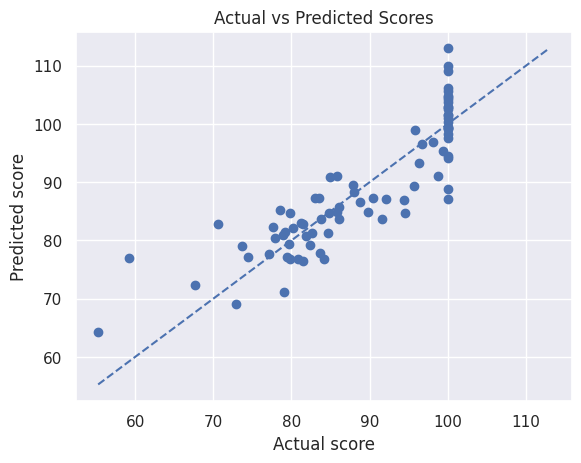

In [ ]:
fig, ax = plt.subplots()
ax.scatter(y_test, pred)
ax.set_xlabel("Actual score")
ax.set_ylabel("Predicted score")
ax.set_title("Actual vs Predicted Scores")

# Reference line for perfect predictions.
limits = [
    min(y_test.min(), pred.min()),
    max(y_test.max(), pred.max())
]
ax.plot(limits, limits, linestyle="--")

plt.show()

## Mini Project Exercise E — Interpret carefully

Write a conclusion addressing:

1. What patterns did the exploratory analysis suggest?
2. How accurate was the model according to RMSE?
3. How much variation did the model explain according to R²?
4. What are at least two limitations of this analysis?
5. Why should these results not be interpreted as proof that a particular factor causes higher scores?

Remember:

**Association, prediction, and causation are different ideas.**

A predictive model can be useful without establishing a causal relationship.

# Part VIII — Core Concepts You Should Be Able to Explain

Before moving on, make sure you can explain these without looking at the code.

## Python

- What is a variable?
- What is a type?
- What is the difference between a list and a dictionary?
- What does an `if` statement do?
- What does a loop do?
- Why use functions?

## NumPy

- What is an array?
- What does `shape` mean?
- What does `axis` mean?
- What is vectorization?
- What is broadcasting?
- Why are arrays useful for numerical computation?

## Pandas

- What is a Series?
- What is a DataFrame?
- What is an index?
- What does filtering do?
- Why is `groupby` useful?
- What does a merge/join accomplish?
- What is missing data?
- What is feature engineering?

## Matplotlib / Seaborn

- When would you use a histogram?
- When would you use a scatter plot?
- What does a box plot show?
- Why does visualization matter for analysis?
- What is the difference between the Matplotlib and Seaborn mental models?

## Scikit-learn

- What are `X` and `y`?
- What is the difference between regression and classification?
- Why split train/test data?
- What is generalization?
- What is data leakage?
- Why can preprocessing need to happen inside a pipeline?
- What does RMSE measure?
- What does R² communicate?
- Why can accuracy be misleading?

# Part IX — Practice Set

These exercises are designed to test whether you understand the concepts rather than whether you can copy syntax.

## Exercise 27 — Python reasoning

What is the difference between these two ideas?

```python
total = total + value
```

and

```python
total += value
```

Then explain why a loop is often unnecessary when NumPy can express the same numerical operation directly.

## Exercise 28 — NumPy reasoning

An array has shape `(1000, 8)`.

Answer:

1. How many observations might it represent?
2. How many variables might it contain?
3. What does `axis=0` preserve?
4. What shape would `array.mean(axis=0)` have?

## Exercise 29 — Pandas reasoning

You have a DataFrame with 1 million customer records.

Why might you prefer:

```python
df[df["age"] >= 18]
```

to manually looping over every row?

What is the difference between a boolean mask and the filtered DataFrame?

## Exercise 30 — Visualization reasoning

You want to know whether sales increase over 12 months.

Why might a line plot be a natural starting point?

What would be wrong with treating months as completely unrelated categories?

## Exercise 31 — Machine-learning reasoning

A model gets:

- training accuracy = 99%
- test accuracy = 71%

What does this pattern suggest may be happening?

Name one concept you would investigate.

## Exercise 32 — Data leakage

You compute the mean of the entire dataset before splitting train/test and use that mean to fill missing values in both sets.

Why can this be considered leakage?

How would a pipeline help?

## Exercise 33 — Model interpretation

A regression model has an R² of 0.82.

What can you reasonably say?

What can you **not** conclude automatically?

Do not equate R² with causality.

# Part X — Final Capstone

Choose a small dataset of your own.

The dataset should contain:

- at least 100 rows,
- at least 3 useful variables,
- at least one numerical variable,
- and either a continuous target or a categorical target if you want to model it.

Your notebook should contain:

## 1. Problem statement

Write:

> "I want to understand/predict ______ using ______."

## 2. Data inspection

Show:

- shape,
- dtypes,
- first rows,
- missing values,
- descriptive statistics.

## 3. Data cleaning

Document:

- missing-value handling,
- duplicate handling,
- obvious data-quality issues.

## 4. Exploratory analysis

Create at least four useful visualizations.

## 5. Feature and target definition

Clearly identify `X` and `y`.

## 6. Train/test split

Explain why it is necessary.

## 7. Baseline model

Fit a simple model.

## 8. Evaluation

Choose appropriate metrics.

## 9. Interpretation

Explain:

- what you learned,
- what the model did well/poorly,
- what assumptions or limitations exist,
- and what you would investigate next.

## 10. Final conclusion

Write a short evidence-based conclusion.

---

# Suggested datasets for practice

You can practice with:

- Iris
- Titanic
- student-performance data
- retail sales
- housing data
- customer churn data

The important part is not the dataset's prestige.

The important part is whether you can go from:

**question → data → inspection → cleaning → visualization → features/target → model → evaluation → interpretation**

# Final Mental Model

A beginner data scientist should not think:

> "Which library function should I use?"

Instead, think:

### 1. What kind of data do I have?

Numbers? Categories? Dates? Text?

### 2. What structure represents it?

Python collection? NumPy array? Pandas DataFrame?

### 3. What question am I asking?

Describe? Compare? Explore relationships? Predict?

### 4. What operation answers that question?

Filter? Aggregate? Visualize? Model?

### 5. What assumptions am I making?

### 6. How do I know the result is useful?

This way of thinking transfers across libraries, datasets, and projects.

The syntax changes. The reasoning does not.

---

## Completion checklist

Before calling yourself comfortable with this course, make sure you can independently:

- manipulate Python variables and collections,
- write functions,
- use NumPy arrays and vectorized operations,
- inspect and transform Pandas DataFrames,
- group and merge tables,
- create and interpret basic plots,
- distinguish descriptive analysis from prediction,
- create `X` and `y`,
- split train/test data,
- fit a basic regression/classification model,
- evaluate predictions,
- recognize overfitting and leakage,
- and explain your results in plain language.

**The objective is not to know every function. The objective is to understand the structure of data-science problems well enough that the functions become tools rather than magic.**